# Notebook `test_modulos`

## Este notebook sirve para probar la modulación del código es de prueba nada más. 

In [1]:
import pathlib, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az 

%load_ext autoreload
%autoreload 2

_cwd = pathlib.Path().resolve()
ROOT = next((p for p in [_cwd, *_cwd.parents] if (p / 'src').exists()), _cwd)
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

DATA_DIR = ROOT / 'data'
IDATA_DIR = DATA_DIR / 'idata'

print(f"ROOT: {ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"IDATA_DIR: {IDATA_DIR}")

ROOT: /Users/oscarostorga/Desktop/Maestría/Tercer_trimestre/Introduction_probabilistic_programming/final-project-pp-dj
DATA_DIR: /Users/oscarostorga/Desktop/Maestría/Tercer_trimestre/Introduction_probabilistic_programming/final-project-pp-dj/data
IDATA_DIR: /Users/oscarostorga/Desktop/Maestría/Tercer_trimestre/Introduction_probabilistic_programming/final-project-pp-dj/data/idata


In [2]:
df = pd.read_csv(DATA_DIR / 'base_modelo_2019_2023.csv')
print(df.shape)
df.head()

(576, 6)


,estado,anio,surtidas,total,institucion,tipo
0,AGUASCALIENTES,2019,4334260,4338906,IMSS,civil
1,AGUASCALIENTES,2020,3676230,3803608,IMSS,civil
2,AGUASCALIENTES,2021,3874201,4163315,IMSS,civil
3,AGUASCALIENTES,2022,4382755,4557129,IMSS,civil
4,AGUASCALIENTES,2023,4971284,5053481,IMSS,civil


In [3]:
from model_data import preparar_modelo_a, preparar_modelo_c

data_a = preparar_modelo_a(df)
data_c = preparar_modelo_c(df)

print('Modelo A — coords:', {k: len(v) for k, v in data_a['coords'].items()})
print('Modelo C — coords:', {k: len(v) for k, v in data_c['coords'].items()})
print('mask_civil:', data_c['mask_civil'])
print('mask_mil  :', data_c['mask_mil'])
assert data_c['mask_civil'].sum() == 3
assert data_c['mask_mil'].sum() == 2
print('OK — dimensiones esperadas')

Modelo A — coords: {'estado': 32, 'anio': 5, 'institucion': 3, 'tipo': 1}
Modelo C — coords: {'estado': 32, 'anio': 5, 'institucion': 5, 'tipo': 2, 'inst_civil': 3, 'inst_mil': 2}
mask_civil: [ True  True  True False False]
mask_mil  : [False False False  True  True]
OK — dimensiones esperadas


## `models.py` — build_modelo_a / build_modelo_c
Solo construye el grafo del modelo, no samplea — debe correr instantáneo.

In [4]:
from models import build_modelo_a, build_modelo_c

modelo_A = build_modelo_a(data_a)
modelo_C = build_modelo_c(data_c)

print(modelo_A)
print()
print(modelo_C)

## Prior predictive check
Verifica que el Modelo C genera valores razonables de θ antes de samplear.

Sampling: [beta0, dev_civil, dev_mil, eff_anio, eff_estado, eff_tipo, k_obs, sigma_anio, sigma_estado, sigma_inst, sigma_tipo]


theta prior — media: 0.8942
theta prior — rango: 0.0332 0.9991


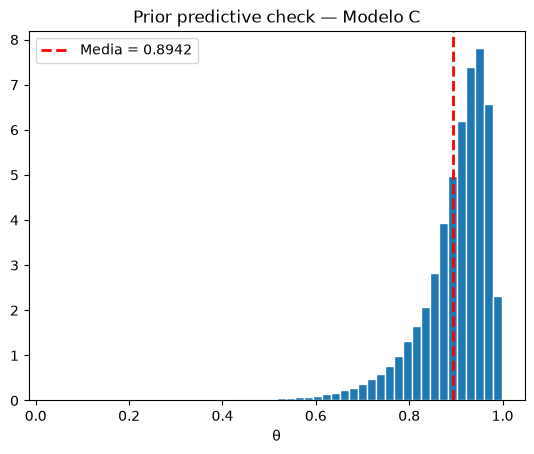

In [5]:
import pymc as pymc

with modelo_C:
    prior_pred = pymc.sample_prior_predictive(samples = 500, random_seed = 42)

theta_prior = prior_pred.prior['theta'].values
print('theta prior — media:', theta_prior.mean().round(4))
print('theta prior — rango:', theta_prior.min().round(4), theta_prior.max().round(4))

plt.hist(theta_prior.flatten(), bins = 50, density = True, edgecolor = 'white')
plt.axvline(theta_prior.mean(), color = "red", linestyle = "--", lw = 2, label = f"Media = {theta_prior.mean():.4f}")
plt.legend()
plt.xlabel('θ')
plt.title('Prior predictive check — Modelo C')
plt.show()


## Muestreo (test rápido)
Pocos draws/tune solo para verificar que el muestreo corre sin error.

In [6]:
with modelo_C:
    idata_test = pymc.sample(
        draws = 2000, tune = 1000, chains = 4,
        target_accept = 0.95, random_seed = 42,
    )

az.summary(idata_test, var_names = ['beta0', 'sigma_estado', 'sigma_anio', 'sigma_tipo', 'sigma_inst'])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, sigma_estado, eff_estado, sigma_anio, eff_anio, sigma_tipo, eff_tipo, sigma_inst, dev_civil, dev_mil]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 7 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,2.133,0.001,2.132,2.134,0.000,0.000,9847.0,6564.0,1.0
sigma_estado,0.386,0.052,0.294,0.480,0.000,0.001,17070.0,5525.0,1.0
sigma_anio,0.576,0.129,0.354,0.816,0.001,0.002,18550.0,5251.0,1.0
sigma_tipo,0.870,0.246,0.447,1.319,0.002,0.003,19341.0,6199.0,1.0
sigma_inst,0.412,0.123,0.211,0.638,0.001,0.002,19910.0,5637.0,1.0


Sampling: [k_obs]


Output()

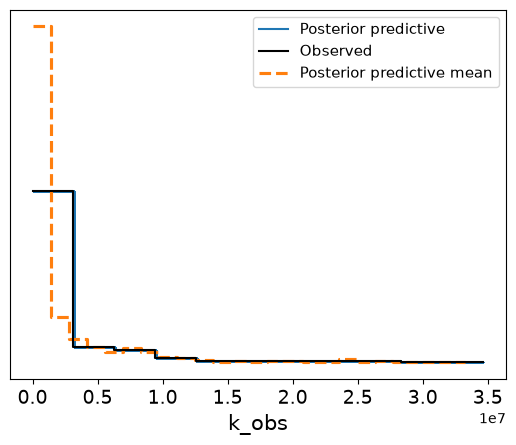

In [7]:
with modelo_C:
    post_pred_test = pymc.sample_posterior_predictive(idata_test, random_seed = 42)

az.plot_ppc(post_pred_test, observed_rug = True)
plt.show()


## Gráficos ArViz del posterior

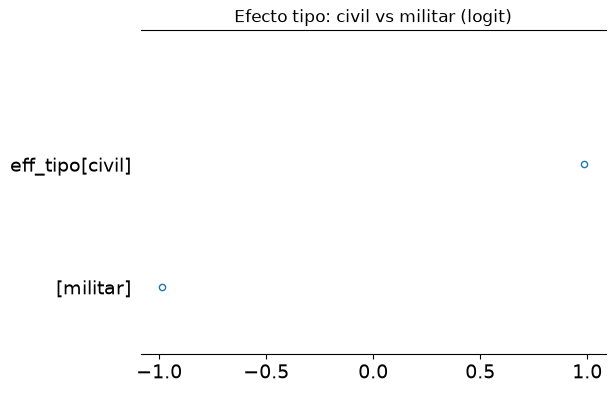

In [8]:
az.plot_forest(idata_test, var_names = ["eff_tipo"], combined = True)
plt.title("Efecto tipo: civil vs militar (logit)")
plt.show()

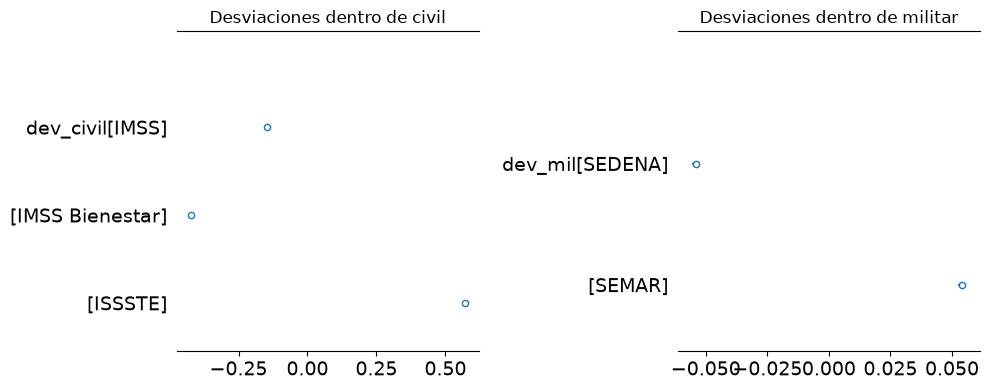

In [9]:
fig, axes = plt.subplots(1, 2, figsize = (10, 4))
az.plot_forest(idata_test, var_names = ["dev_civil"], combined = True, ax = axes[0])
az.plot_forest(idata_test, var_names = ["dev_mil"], combined = True, ax = axes[1])
axes[0].set_title("Desviaciones dentro de civil")
axes[1].set_title("Desviaciones dentro de militar")
plt.tight_layout()
plt.show()

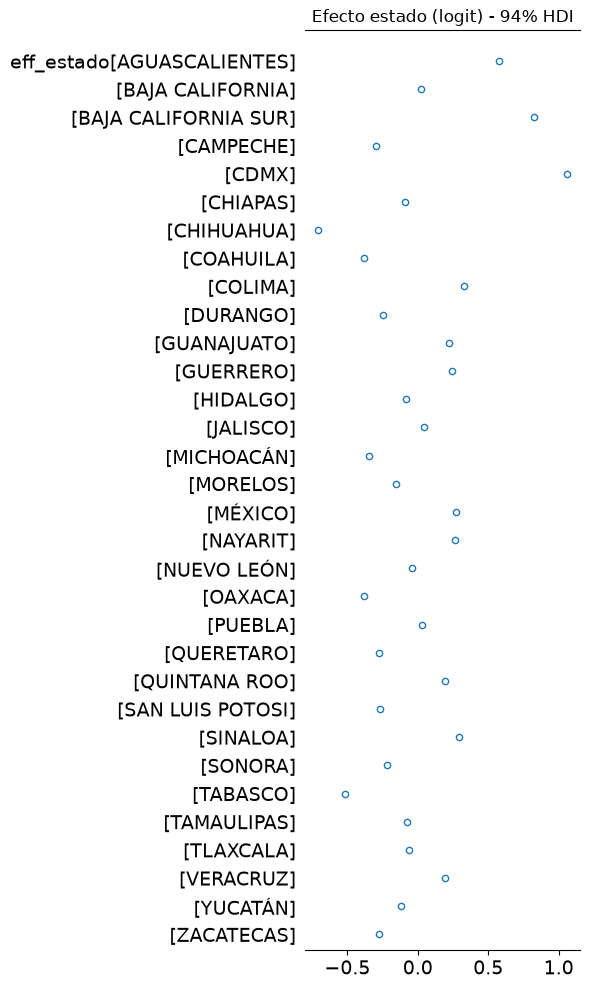

In [10]:
az.plot_forest(idata_test, var_names = ["eff_estado"], combined = True, figsize = (6, 10))
plt.title("Efecto estado (logit) - 94% HDI")
plt.tight_layout()
plt.show()

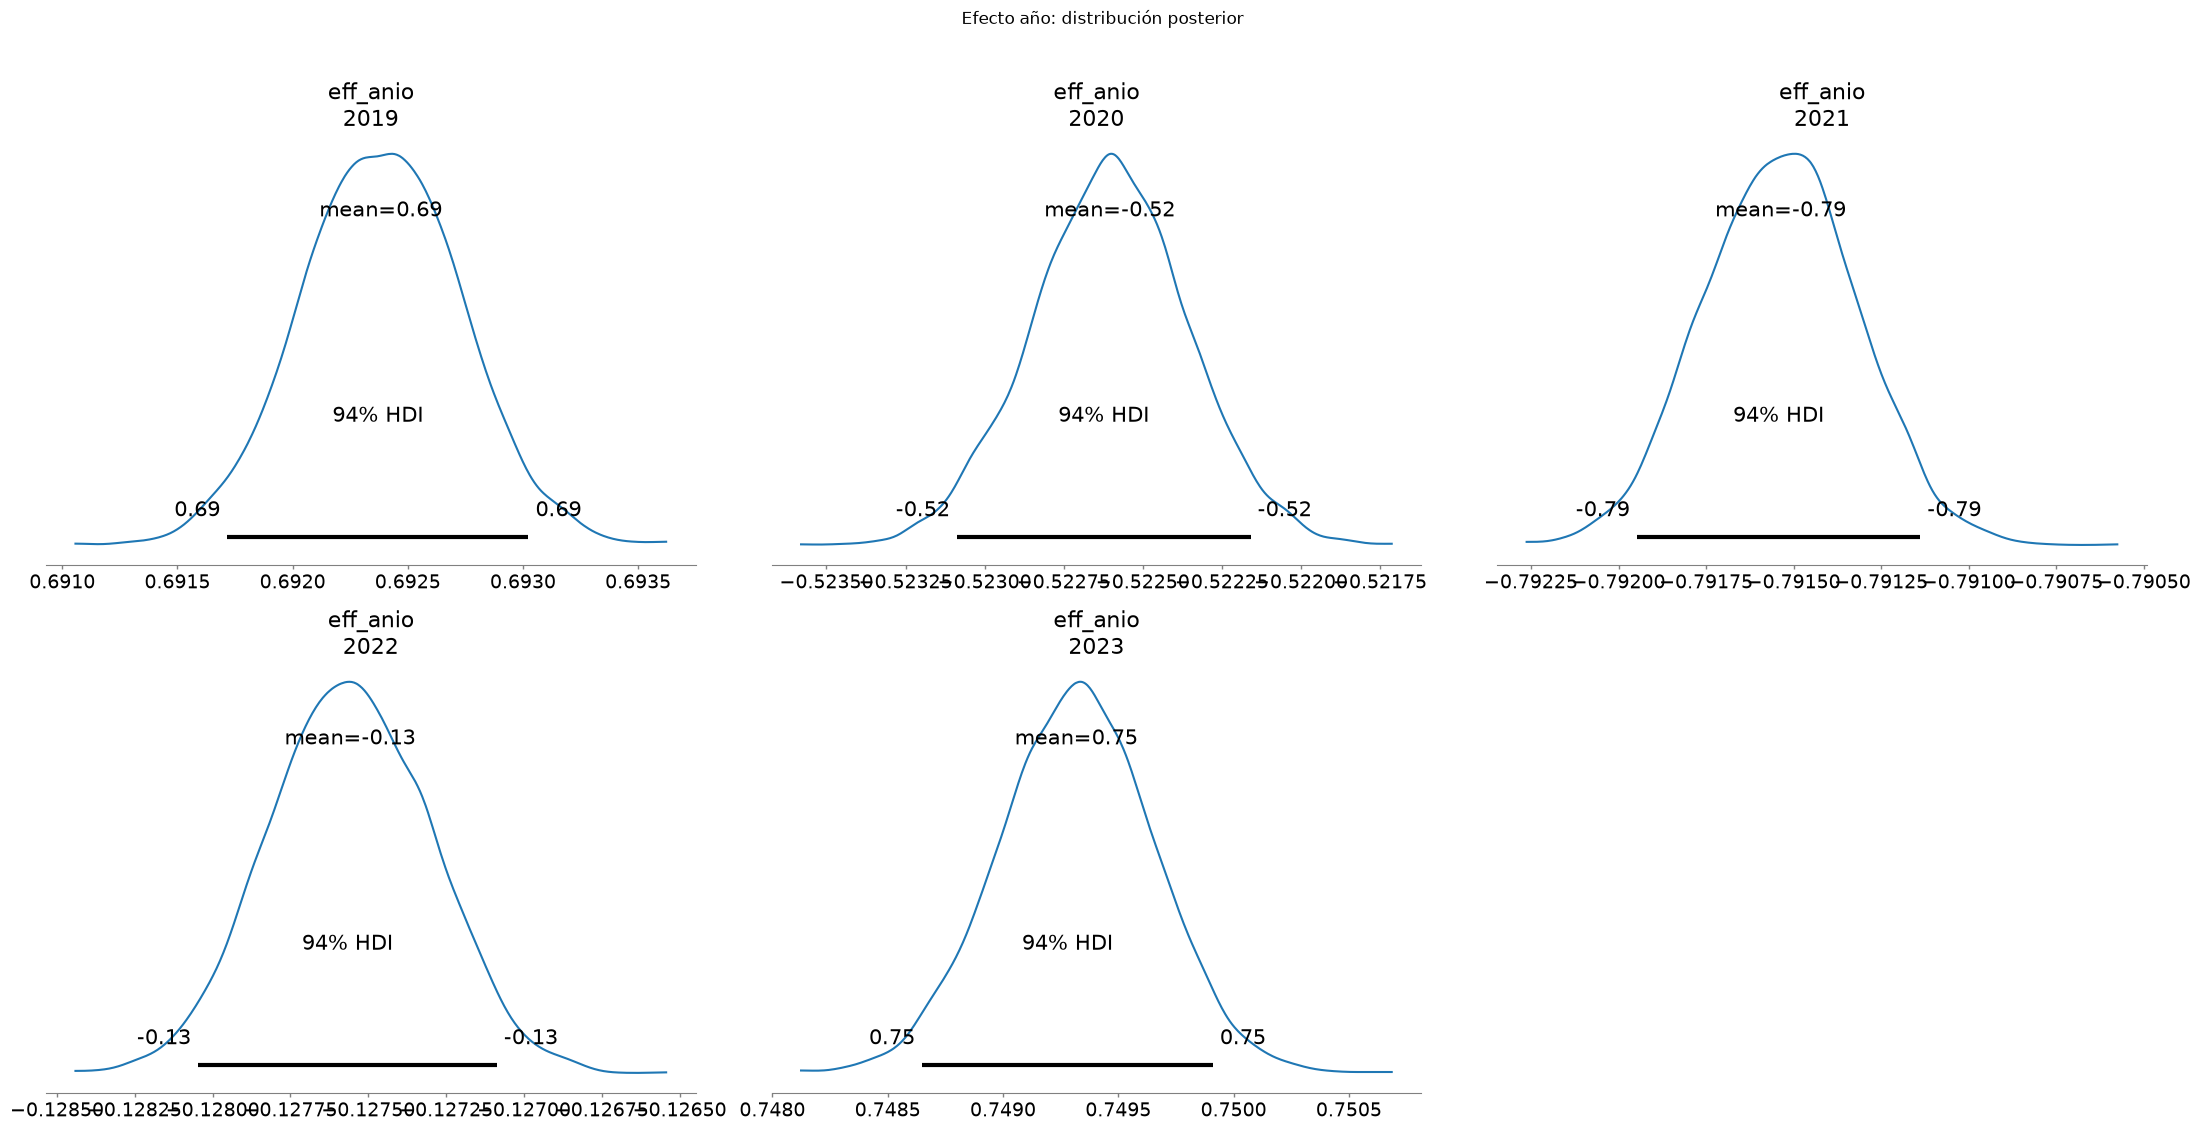

In [11]:
az.plot_posterior(idata_test, var_names = ["eff_anio"])
plt.suptitle("Efecto año: distribución posterior", y = 1.02)
plt.tight_layout()
plt.show()

## `analysis.py` — extracción del posterior


In [12]:
from analysis import (
    extract_posterior,
    brecha_civil_militar,
    ranking_instituciones,
    ranking_estados,
    estados_estructurales,
    escenario,
    declaraciones_politica_publica,
)

post = extract_posterior(idata_test, data_c)

print('Keys en post:', list(post.keys()))
print('Instituciones:', post['insts'])
print('Tipos:', post['tipos'])


Keys en post: ['beta0', 'eff_inst', 'eff_anio', 'eff_estado', 'insts', 'estados', 'anios', 'eff_tipo', 'tipos']
Instituciones: ['IMSS', 'IMSS Bienestar', 'ISSSTE', 'SEDENA', 'SEMAR']
Tipos: ['civil', 'militar']


In [13]:
print('=== Brecha civil/militar ===')
display(brecha_civil_militar(post))

print('=== Ranking instituciones ===')
display(ranking_instituciones(post))


=== Brecha civil/militar ===


,tipo,theta_media,ic_2.5,ic_97.5
0,civil,0.957687,0.957655,0.957719
1,militar,0.758862,0.758529,0.759192


=== Ranking instituciones ===


,institucion,theta_media,ic_2.5,ic_97.5,receta_incompleta
0,ISSSTE,0.975630,0.975606,0.975654,0.024370
1,IMSS,0.951287,0.951270,0.951304,0.048713
2,IMSS Bienestar,0.936831,0.936707,0.936953,0.063169
3,SEMAR,0.768625,0.768115,0.769122,0.231375
4,SEDENA,0.748822,0.748406,0.749249,0.251178


In [14]:
print('=== Ranking estados (primeros 10) ===')
display(ranking_estados(post).head(10))

print('=== Estados estructurales (umbral 0.95) ===')
display(estados_estructurales(post))


=== Ranking estados (primeros 10) ===


,estado,eff_estado_media,ic_2.5,ic_97.5,p_eff_negativo
0,CHIHUAHUA,-0.708564,-0.709464,-0.707686,1.0
1,TABASCO,-0.518693,-0.520634,-0.516762,1.0
2,COAHUILA,-0.382003,-0.383065,-0.380942,1.0
3,OAXACA,-0.380813,-0.382684,-0.378905,1.0
4,MICHOACÁN,-0.348287,-0.349432,-0.347150,1.0
5,CAMPECHE,-0.298862,-0.301384,-0.296295,1.0
6,QUERETARO,-0.273913,-0.275497,-0.272294,1.0
7,ZACATECAS,-0.272630,-0.274444,-0.270773,1.0
8,SAN LUIS POTOSI,-0.270123,-0.271524,-0.268723,1.0
9,DURANGO,-0.249467,-0.250997,-0.247946,1.0


=== Estados estructurales (umbral 0.95) ===


,estado,eff_estado_media,ic_2.5,ic_97.5,p_eff_negativo
0,CHIHUAHUA,-0.708564,-0.709464,-0.707686,1.0
1,TABASCO,-0.518693,-0.520634,-0.516762,1.0
2,COAHUILA,-0.382003,-0.383065,-0.380942,1.0
3,OAXACA,-0.380813,-0.382684,-0.378905,1.0
4,MICHOACÁN,-0.348287,-0.349432,-0.347150,1.0
5,CAMPECHE,-0.298862,-0.301384,-0.296295,1.0
6,QUERETARO,-0.273913,-0.275497,-0.272294,1.0
7,ZACATECAS,-0.272630,-0.274444,-0.270773,1.0
8,SAN LUIS POTOSI,-0.270123,-0.271524,-0.268723,1.0
9,DURANGO,-0.249467,-0.250997,-0.247946,1.0


In [15]:
print('=== Escenario: IMSS, CHIHUAHUA, 2021 ===')
print(escenario(post, inst = 'IMSS', estado = 'CHIHUAHUA', anio = 2021))

print()
print('=== Declaraciones de política pública ===')
for d in declaraciones_politica_publica(post):
    print('-', d['titulo'])
    print(' ', d['detalle'])


=== Escenario: IMSS, CHIHUAHUA, 2021 ===
{'institucion': 'IMSS', 'estado': 'CHIHUAHUA', 'anio': 2021, 'theta_media': np.float64(0.8133264087891491), 'ic_2.5': np.float64(0.8131870027936083), 'ic_97.5': np.float64(0.8134643102792034), 'p_receta_incompleta': np.float64(0.18667359121085092)}

=== Declaraciones de política pública ===
- P(sistema civil > sistema militar) = 100%
  Brecha media de 19.9% puntos porcentuales.
- P(ISSSTE > IMSS en surtimiento) = 100%
  El ISSSTE supera al IMSS con certeza total pese a ser menos discutido públicamente.
- 18 estados con problema estructural confirmado (P(eff_estado<0) > 95%)
  IMSS, ISSSTE e IMSS Bienestar están simultáneamente por debajo del promedio nacional en estos estados.


## `plots.py` — visualizaciones

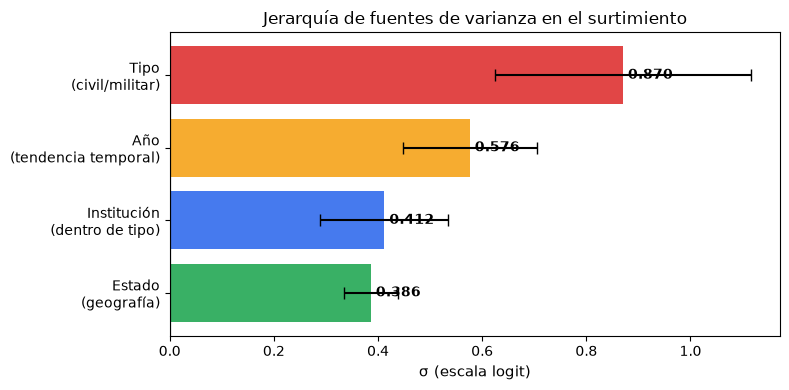

In [16]:
from plots import (
    plot_varianzas,
    plot_brecha_civil_militar,
    plot_ranking_instituciones,
    plot_tendencia_anual,
    plot_ranking_geografico,
    plot_escenarios_criticos,
)
from analysis import theta_posterior

colores_inst = {
    'ISSSTE': '#1d4ed8', 'IMSS': '#2563eb', 'IMSS Bienestar': '#60a5fa',
    'SEDENA': '#b91c1c', 'SEMAR': '#ef4444',
}

plot_varianzas(idata_test)
plt.show()


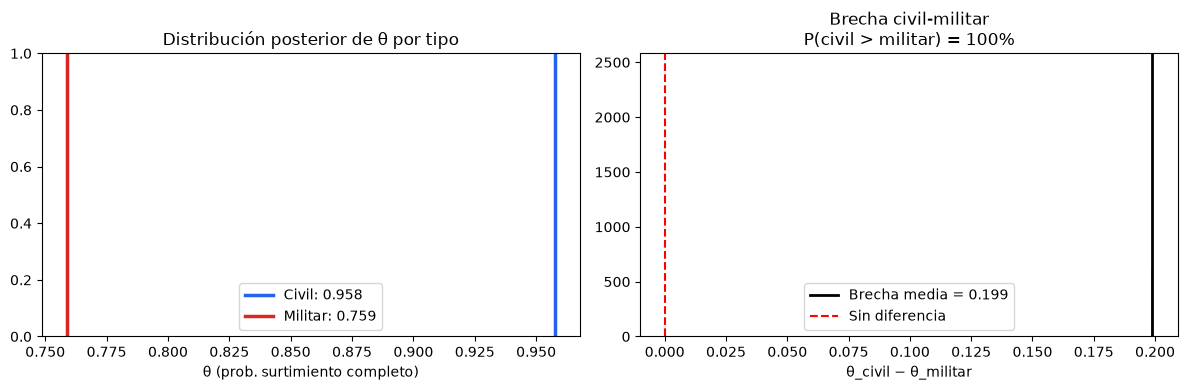

In [17]:
plot_brecha_civil_militar(post)
plt.show()

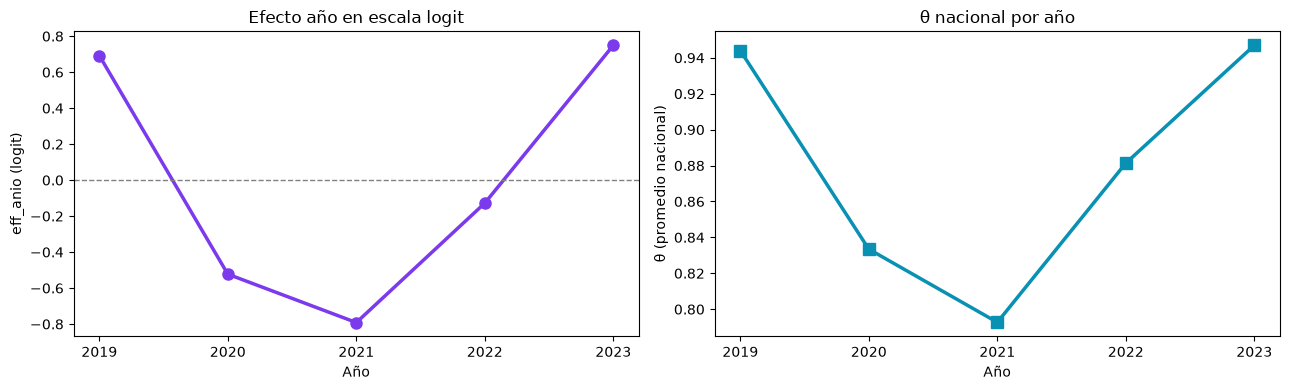

In [18]:
plot_tendencia_anual(post)
plt.show()

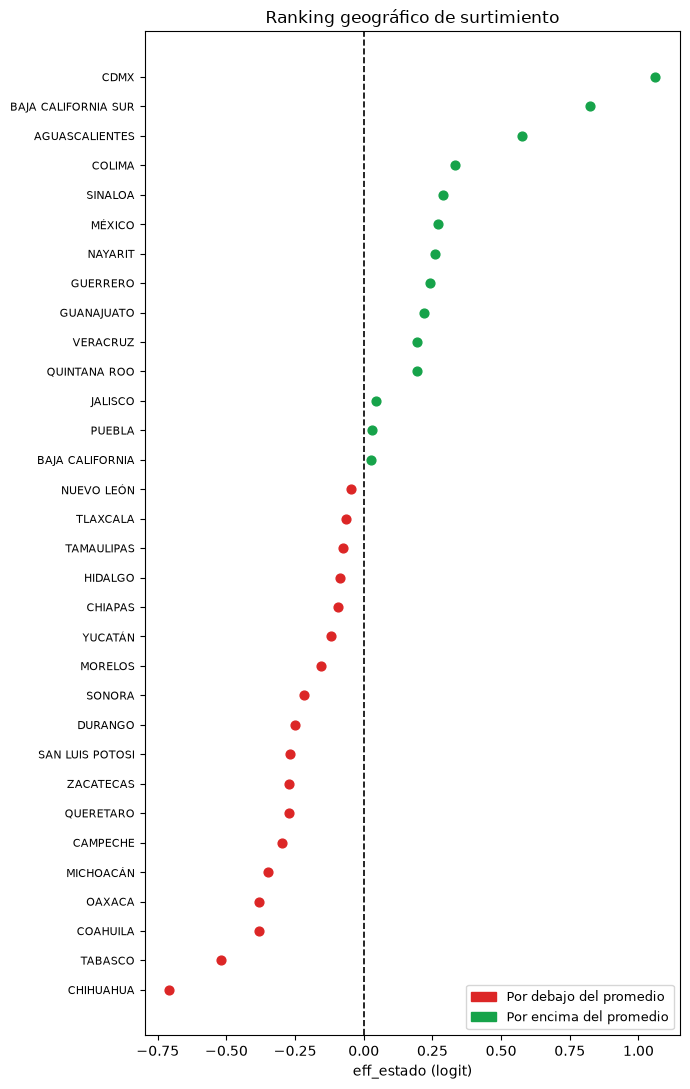

In [19]:
plot_ranking_geografico(post)
plt.show()

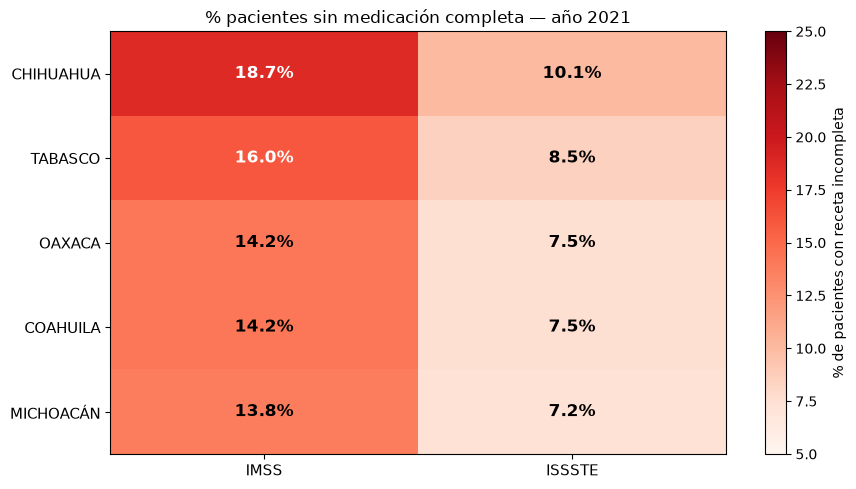

In [20]:
plot_escenarios_criticos(
    post,
    estados = ['CHIHUAHUA', 'TABASCO', 'OAXACA', 'COAHUILA', 'MICHOACÁN'],
    instituciones = ['IMSS', 'ISSSTE'],
    anio = 2021,
    theta_posterior_fn = theta_posterior,
)
plt.show()


## `logit_frecuente.py`  GLM binomial logit (baseline frecuentista)
Equivalente frecuentista del Modelo A y C: efectos fijos para estado, año
e institución, sin pooling parcial. Sirve como punto de comparación con
el modelo bayesiano jerárquico.


## Modelo Logit Frecuentista - Formulación e Interpretación

### Formulación

Como punto de comparación con el modelo bayesiano jerárquico, se ajustó un **Modelo Lineal Generalizado (GLM) binomial con liga logit** usando máxima verosimilitud. La estructura matemática es idéntica al modelo bayesiano. 

$$\text{logit}(\theta_i) = \log\frac{\theta_i}{1-\theta_i} = \beta_0 + \beta_{\text{estado}} + \beta_{\text{año}} + \beta_{\text{institución}}$$

donde $\theta_i\$ es la probabilidad de que una receta sea surtida completamente en la combinación $i$ (estado * año * institución).

La diferencia fundamental respecto al modelo bayesiano es que aquí los efectos son **fijos con variables dummy**, es decir, no hay pooling parcial entre estados ni entre años. Cada categoría recibe su propio coeficiente estimado de forma independiente. 

Dado que los datos están agregados (cada fila representa millones de recetas individuales), se usa `freq_weights = total` para que el modelo pondere correctamente la verosimilitud según el volumen de recetas de cada celda. 

Se ajustaron dos versiones, uno por cada modelo: 

- **Modelo A**: solo instituciones civiles (IMSS, IMSS Bienestar, ISSSTE) dando como total 415 observaciones y 38 parámetros. 
- **Modelo B**: todas las instituciones incluyendo SEDENA y SEMAR, dando un total de 576 observaciones y 40 parámetros. 



In [21]:
from logit_frecuente import fit_logit_a, fit_logit_c, resumen_coeficientes

result_a = fit_logit_a(df)
result_c = fit_logit_c(df)

print(result_a.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   prop   No. Observations:                  415
Model:                            GLM   Df Residuals:               1310833705
Model Family:                Binomial   Df Model:                           37
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.8325e+08
Date:                Thu, 02 Jul 2026   Deviance:                   5.5042e+06
Time:                        03:30:25   Pearson chi2:                 5.63e+06
No. Iterations:                    11   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [22]:
print(result_c.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   prop   No. Observations:                  576
Model:                            GLM   Df Residuals:               1318600758
Model Family:                Binomial   Df Model:                           39
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.8645e+08
Date:                Thu, 02 Jul 2026   Deviance:                   6.6238e+06
Time:                        03:30:25   Pearson chi2:                 6.92e+06
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

#### Coeficientes en tabla limpia

In [23]:
res_a = resumen_coeficientes(result_a)
res_c = resumen_coeficientes(result_c)

print('=== Modelo A (civiles) ===')
display(res_a[res_a['variable'].str.contains('institucion|anio|Intercept')])

print('=== Modelo C (civil + militar) ===')
display(res_c[res_c['variable'].str.contains('institucion|anio|Intercept')])

=== Modelo A (civiles) ===


,variable,coef,ic_2.5,ic_97.5,p_valor,theta
0,Intercept,4.250172,4.247707,4.252637,0.0,0.999797
32,C(anio)[T.2020],-1.227940,-1.228891,-1.226988,0.0,0.953568
33,C(anio)[T.2021],-1.507815,-1.508735,-1.506896,0.0,0.939480
34,C(anio)[T.2022],-0.831425,-0.832405,-0.830445,0.0,0.968285
35,C(anio)[T.2023],0.086457,0.085315,0.087599,0.0,0.987088
36,C(institucion)[T.IMSS Bienestar],-0.266748,-0.268811,-0.264684,0.0,0.981719
37,C(institucion)[T.ISSSTE],0.716963,0.715926,0.718000,0.0,0.993085


=== Modelo C (civil + militar) ===


,variable,coef,ic_2.5,ic_97.5,p_valor,theta
0,Intercept,4.239001,4.236540,4.241463,0.0,0.999792
32,C(anio)[T.2020],-1.214985,-1.215929,-1.214041,0.0,0.953647
33,C(anio)[T.2021],-1.483921,-1.484832,-1.483009,0.0,0.940200
34,C(anio)[T.2022],-0.819940,-0.820910,-0.818971,0.0,0.968295
35,C(anio)[T.2023],0.056930,0.055814,0.058047,0.0,0.986559
36,C(institucion)[T.IMSS Bienestar],-0.275168,-0.277228,-0.273107,0.0,0.981364
37,C(institucion)[T.ISSSTE],0.717874,0.716837,0.718910,0.0,0.993014
38,C(institucion)[T.SEDENA],-1.879527,-1.881823,-1.877232,0.0,0.913684
39,C(institucion)[T.SEMAR],-1.771315,-1.774225,-1.768404,0.0,0.921845


### Interpretación de resultados

#### Intercepto: categoría de referencia

El intercepto en este caso representa la combinación de referencia: **AGUASCALIENTES + IMSS + 2019** (primera categoría alfabética de cada variable). 

$$\hat{\beta}_0 = 4.25 \Rightarrow \theta = \text{invlogit}(4.25) = 0.986$$

El IMSS en Aguascalientes en 2019 surtía el 98.6% de las recetas según el modelo frecuentista. Todos los demás coeficientes son desviaciones respecto a este punto. 

#### Efectos de institución

| Institución | Coeficiente | Interpretación |
|-------------|-------------|----------------|
| IMSS | 0 (referencia) | — |
| ISSSTE | +0.717 | Supera al IMSS en 0.72 logits |
| IMSS Bienestar | −0.267 | Por debajo del IMSS en 0.27 logits |
| SEDENA | −1.880 | La mayor brecha del sistema |
| SEMAR | −1.771 | Similar a SEDENA, severamente por debajo |


La brecha entre el sistema civil y el militar queda capturada en los coeficientes de SEDENA (-1.880) y SEMAR (-1.771) respecto al IMSS. Estas diferencias son más que el doble que el efecto del peor estado que es Chihuahua: -1.288, confirmando que el tipo de sistema (civil/militar) es la fuente de variación dominante. 

#### Efecto temporal - impacto del COVID-19

| Año | Coeficiente | Interpretación |
|---|---|---|
| 2019 | 0 (referencia) | Mejor año del período |
| 2020 | −1.228 | Primera caída COVID |
| 2021 | −1.508 | Peor año: COVID + reestructura INSABI |
| 2022 | −0.831 | Recuperación parcial |
| 2023 | +0.087 | Prácticamente recuperado |

La caída de 2019 a 2021 representa **1.508 logits**, que es equivalente a mover un estado del promedio nacional al nivel de Chihuahua (el peor estado estructural).

#### Efecto geográfico 

Los estados con mayor desabasto estructural (coeficientes más negativos):

| Estado | Coeficiente |
|---|---|
| Chihuahua | −1.288 |
| Tabasco | −1.116 |
| Oaxaca | −1.006 |
| Coahuila | −0.960 |

CDMX (+0.534) presenta el mayor efecto positivo, consistente con su concentración de infraestructura logística y bodegas de distribución.

### Limitaciones frente al modelo bayesiano 

Aunque el modelo frecuentista recupera los mismos patrones cualitativos, tiene
tres limitaciones importantes:

1. **Intervalos de confianza artificialmente angostos**: con `freq_weights` escalando por millones de observaciones, los errores estándar se vuelven microscópicos (~0.001). Esto no refleja incertidumbre real sino el tamaño artificial de la muestra.

2. **P-valores inútiles**: con 1,310 millones de observaciones efectivas, absolutamente todos los coeficientes resultan significativos (p=0.000), independientemente de su relevancia práctica.

3. **Sin pooling parcial**: cada estado y cada año reciben coeficientes independientes. El modelo bayesiano jerárquico estabiliza las estimaciones compartiendo información estadística entre grupos vía los hiperpriors (σ_estado, σ_año), lo que produce estimaciones más conservadoras pero más robustas — especialmente para estados con menor volumen de recetas.